In [133]:
# Lucky Choudhary
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

df = pd.read_csv("../data/processed/cleaned_walmart.csv")

# to convert date(string) into datetime formate
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
print(df.head())

(421570, 18)
   Store  Dept       Date  Weekly_Sales  Temperature  Fuel_Price  MarkDown1  \
0      1     1 2010-02-05      24924.50        42.31       2.572        NaN   
1      1     1 2010-02-12      46039.49        38.51       2.548        NaN   
2      1     1 2010-02-19      41595.55        39.93       2.514        NaN   
3      1     1 2010-02-26      19403.54        46.63       2.561        NaN   
4      1     1 2010-03-05      21827.90        46.50       2.625        NaN   

   MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment Type  \
0        NaN        NaN        NaN        NaN  211.096358         8.106    A   
1        NaN        NaN        NaN        NaN  211.242170         8.106    A   
2        NaN        NaN        NaN        NaN  211.289143         8.106    A   
3        NaN        NaN        NaN        NaN  211.319643         8.106    A   
4        NaN        NaN        NaN        NaN  211.350143         8.106    A   

     Size  IsHoliday  Year  Mon

In [134]:
print(df.isnull().sum())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
IsHoliday            0
Year                 0
Month                0
dtype: int64


## Missing Value Handling

MarkDown columns contain NaN values which represent absence of promotional activities.  
These were replaced with 0 to accurately reflect no discount scenario.

In [135]:
# Replacing all markdown columns data that are null to zero, so it can be anyalzied in future without and problem
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)

In [136]:
print(df[markdown_cols].isnull().sum())

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [137]:
# Creating new features such as Total markdown, Store size category, Sale per size
df['Total_MarkDown'] = df[markdown_cols].sum(axis=1)

In [138]:
df['Store_Size_Category'] = df['Size'].apply(lambda x: 'Small' if x < 100000 else 'Medium' if x < 150000 else 'Large')

In [139]:
df['Sales_per_Size'] = df['Weekly_Sales'] / df['Size']

In [140]:
df['Holiday_Flag'] = df['IsHoliday'].apply(lambda x: 'Holiday' if x else 'Non-Holiday')

In [141]:
df['Sales_Category'] = df['Weekly_Sales'].apply(
    lambda x: 'Low' if x < 10000 else 'Medium' if x < 20000 else 'High'
)

In [142]:
df['Discount_Ratio'] = df['Total_MarkDown'] / df['Weekly_Sales'].replace(0, 1)
# Replace zero to one to avoide calulation error while dividing
df['Performance_Score'] = df['Weekly_Sales'] * (1 - df['Discount_Ratio'])

In [143]:
df['Quarter'] = df['Date'].dt.quarter

In [144]:
df['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [145]:
# Sales by Store Type
df.groupby('Type')['Weekly_Sales'].mean()

# Sales by Store Size Category
df.groupby('Store_Size_Category')['Weekly_Sales'].mean()

Store_Size_Category
Large     20912.675438
Medium    14371.810421
Small      8580.993002
Name: Weekly_Sales, dtype: float64

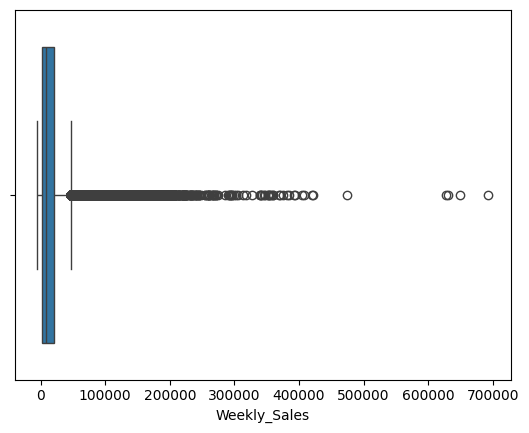

In [146]:
# Create folder if not exists
os.makedirs("../images", exist_ok=True)

# Create plot
plt.figure()
sns.boxplot(x=df['Weekly_Sales'])

# Save image
plt.savefig("../images/weekly_sales_boxplot.png")

# Show plot
plt.show()

In [147]:
print(df.isnull().sum())
print(df.duplicated().sum())

Store                  0
Dept                   0
Date                   0
Weekly_Sales           0
Temperature            0
Fuel_Price             0
MarkDown1              0
MarkDown2              0
MarkDown3              0
MarkDown4              0
MarkDown5              0
CPI                    0
Unemployment           0
Type                   0
Size                   0
IsHoliday              0
Year                   0
Month                  0
Total_MarkDown         0
Store_Size_Category    0
Sales_per_Size         0
Holiday_Flag           0
Sales_Category         0
Discount_Ratio         0
Performance_Score      0
Quarter                0
dtype: int64
0


In [148]:
df.to_csv("../data/processed/final_walmart.csv", index=False)

print("Final cleaned data saved")

Final cleaned data saved
